# US Macroeconomic Data Preparation

**Imports & Setup**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings("ignore")

from fredapi import Fred

plt.style.use("default")

# ── FRED API key
# Replace with your own free key from https://fred.stlouisfed.org/docs/api/api_key.html
FRED_API_KEY = "Your API Key Here"
fred = Fred(api_key=FRED_API_KEY)

# ── Date range
START = "2007-01-01"
END   = "2023-12-31"

FRED_SERIES = {
    "CPIAUCSL" : "CPI (Inflation)",
    "UNRATE"   : "Unemployment Rate (%)",
    "FEDFUNDS" : "Fed Funds Rate (%)",
    "INDPRO"   : "Industrial Production Index",
}

print("Date range :", START, " ->  ", END)
print("Series     :", list(FRED_SERIES.keys()))

Date range : 2007-01-01  ->   2023-12-31
Series     : ['CPIAUCSL', 'UNRATE', 'FEDFUNDS', 'INDPRO']


**Database Connection**

In [ ]:
# ── SQL Server connection setup
import pyodbc, urllib
from sqlalchemy import create_engine, text

SERVER   = r'localhost'              # e.g. 'localhost', '(LocalDB)\MSSQLLocalDB'
DATABASE = 'MacroSentimentDB'             # database that contains the 'core' schema

conn_str = (
    f'DRIVER={{ODBC Driver 17 for SQL Server}};'
    f'SERVER={SERVER};'
    f'DATABASE={DATABASE};'
    f'Trusted_Connection=yes;'
)
engine = create_engine(
    f'mssql+pyodbc:///?odbc_connect={urllib.parse.quote_plus(conn_str)}',
    fast_executemany=True,
)

with engine.connect() as con:
    row = con.execute(text('SELECT @@SERVERNAME AS srv, DB_NAME() AS db')).fetchone()
    print(f'Connected  →  server: {row.srv}  |  database: {row.db}')


Connected  →  server: Lara  |  database: MacroSentimentDB


**Download Data from FRED API**

In [3]:
def fetch_fred(series_id, label, start, end):
    s = fred.get_series(series_id, observation_start=start, observation_end=end)
    s.index = pd.to_datetime(s.index)
    s.name  = series_id
    print(f"  [{series_id}]  {label:<35}  {len(s):>4} obs  "
          f"{s.index[0].date()} -> {s.index[-1].date()}")
    return s

print("Fetching macroeconomic data from FRED...")

cpi      = fetch_fred("CPIAUCSL", "Consumer Price Index",        START, END)
unrate   = fetch_fred("UNRATE",   "Unemployment Rate",           START, END)
fedfunds = fetch_fred("FEDFUNDS", "Fed Funds Rate",              START, END)
indpro   = fetch_fred("INDPRO",   "Industrial Production Index", START, END)

# Merge into a single monthly DataFrame
macro_raw = pd.concat([cpi, unrate, fedfunds, indpro], axis=1)
macro_raw = macro_raw.resample("MS").last()
macro_raw = macro_raw.loc[START:END]
macro_raw.index.name = "Date"

print("Combined shape :", macro_raw.shape)
print("Period         :", macro_raw.index[0].date(), " ->  ", macro_raw.index[-1].date())
macro_raw.head(8)

Fetching macroeconomic data from FRED...
  [CPIAUCSL]  Consumer Price Index                  204 obs  2007-01-01 -> 2023-12-01
  [UNRATE]  Unemployment Rate                     204 obs  2007-01-01 -> 2023-12-01
  [FEDFUNDS]  Fed Funds Rate                        204 obs  2007-01-01 -> 2023-12-01
  [INDPRO]  Industrial Production Index           204 obs  2007-01-01 -> 2023-12-01
Combined shape : (204, 4)
Period         : 2007-01-01  ->   2023-12-01


,CPIAUCSL,UNRATE,FEDFUNDS,INDPRO
Date,,,,
2007-01-01,203.437,4.6,5.25,99.8346
2007-02-01,204.226,4.5,5.26,100.7753
2007-03-01,205.288,4.4,5.26,100.9547
2007-04-01,205.904,4.5,5.25,101.6334
2007-05-01,206.755,4.4,5.25,101.7306
2007-06-01,207.234,4.6,5.25,101.7893
2007-07-01,207.603,4.7,5.26,101.6672
2007-08-01,207.667,4.6,5.02,101.8630


**Insert Raw FRED Data → `core.core_macro_indicators_monthly`**


In [4]:
# ── Build macro insert DataFrame from raw FRED pull 
import pandas as pd
from sqlalchemy import text

# Query US region_id
with engine.connect() as con:
    us_region = con.execute(text("SELECT region_id FROM core.source_regions WHERE region_code = 'US'")).scalar()
    if not us_region:
        us_region = 1

# Query existing records from DB to map keys and avoid duplicates
with engine.connect() as con:
    db_macro = pd.read_sql(
        text('SELECT month_date, source_agency, region_id, indicator_name FROM core.monthly_macro_indicators'), 
        con
    )

dates = pd.to_datetime(macro_raw.index).date
source_agency = 'FRED'

# Unpivot macro_raw to long format
macro_long = macro_raw.reset_index().melt(id_vars=['Date'], var_name='indicator_name', value_name='indicator_value')
macro_long = macro_long.rename(columns={'Date': 'month_date'})
macro_long['month_date'] = macro_long['month_date'].dt.date
macro_long['source_agency'] = source_agency
macro_long['region_id'] = us_region

# Map units
unit_map = {
    'CPIAUCSL': 'Index',
    'UNRATE': '%',
    'FEDFUNDS': '%',
    'INDPRO': 'Index'
}
macro_long['unit'] = macro_long['indicator_name'].map(unit_map)
macro_long = macro_long.dropna(subset=['indicator_value'])

new_macro_insert = macro_long.copy()
if not db_macro.empty:
    db_macro['month_date'] = pd.to_datetime(db_macro['month_date']).dt.date
    merged = new_macro_insert.merge(db_macro, on=['month_date', 'source_agency', 'region_id', 'indicator_name'], how='left', indicator=True)
    new_macro_insert = merged[merged['_merge'] == 'left_only'].drop(columns=['_merge'])

print(f'New macro rows to insert: {len(new_macro_insert)}')
if len(new_macro_insert) > 0:
    print(new_macro_insert.head(3))
else:
    print('All macro indicator rows already exist in DB.')


New macro rows to insert: 816
   month_date indicator_name  indicator_value source_agency  region_id   unit
0  2007-01-01       CPIAUCSL          203.437          FRED          1  Index
1  2007-02-01       CPIAUCSL          204.226          FRED          1  Index
2  2007-03-01       CPIAUCSL          205.288          FRED          1  Index


In [5]:
# ── Bulk-insert new macro indicators into monthly_macro_indicators ───
from sqlalchemy import text

if len(new_macro_insert) == 0:
    print('No new macro rows to insert. Skipping insert.')
else:
    with engine.begin() as con:
        # IDENTITY_INSERT is not needed if we rely on DB auto-increment for record_id
        new_macro_insert.to_sql(
            name      = 'monthly_macro_indicators',
            schema    = 'core',
            con       = con,
            if_exists = 'append',
            index     = False,
            method    = 'multi',
            chunksize = 250,
        )

    print(f'core.monthly_macro_indicators  →  {len(new_macro_insert)} new rows inserted.')

# Verify
with engine.connect() as con:
    cnt = con.execute(text('SELECT COUNT(*) FROM core.monthly_macro_indicators')).scalar()
    sample = con.execute(text(
        'SELECT TOP 3 record_id, month_date, source_agency, region_id, indicator_name, indicator_value, unit ' 
        'FROM core.monthly_macro_indicators ORDER BY record_id'
    )).fetchall()

print(f'Table now contains : {cnt} total rows')
print('\nSample rows:')
for r in sample:
    print(' ', dict(r._mapping))


core.monthly_macro_indicators  →  816 new rows inserted.
Table now contains : 816 total rows

Sample rows:
  {'record_id': 1, 'month_date': datetime.date(2007, 1, 1), 'source_agency': 'FRED', 'region_id': 1, 'indicator_name': 'CPIAUCSL', 'indicator_value': 203.437, 'unit': 'Index'}
  {'record_id': 2, 'month_date': datetime.date(2007, 2, 1), 'source_agency': 'FRED', 'region_id': 1, 'indicator_name': 'CPIAUCSL', 'indicator_value': 204.226, 'unit': 'Index'}
  {'record_id': 3, 'month_date': datetime.date(2007, 3, 1), 'source_agency': 'FRED', 'region_id': 1, 'indicator_name': 'CPIAUCSL', 'indicator_value': 205.288, 'unit': 'Index'}


**Feature Engineering**

In [ ]:
macro = macro_raw.copy()

# Inflation: Month-over-Month and Year-over-Year % change of CPI
macro["Inflation_MoM"] = macro["CPIAUCSL"].pct_change() * 100
macro["Inflation_YoY"] = macro["CPIAUCSL"].pct_change(12) * 100

# Industrial Production: MoM % change
macro["IP_MoM"] = macro["INDPRO"].pct_change() * 100

# UNRATE and FEDFUNDS are already in % units - no transform needed

# Drop NaN rows introduced by pct_change lags
macro = macro.dropna()

print("Engineered columns:")
for col in macro.columns:
    print("  -", col)
print("\nFinal shape:", macro.shape)
macro.describe().round(3)

Engineered columns:
  - CPIAUCSL
  - UNRATE
  - FEDFUNDS
  - INDPRO
  - Inflation_MoM
  - Inflation_YoY
  - IP_MoM

Final shape: (192, 7)


,CPIAUCSL,UNRATE,FEDFUNDS,INDPRO,Inflation_MoM,Inflation_YoY,IP_MoM
count,192.000,192.000,192.000,192.000,192.000,192.000,192.000
mean,245.507,6.126,0.961,98.267,0.198,2.457,0.001
std,25.594,2.283,1.375,4.561,0.327,2.114,1.373
min,211.398,3.400,0.050,84.562,-1.771,-1.959,-13.188
25%,227.687,4.000,0.100,96.740,0.051,1.233,-0.321
50%,238.025,5.550,0.180,99.729,0.208,1.987,0.100
75%,257.070,8.025,1.550,101.256,0.335,3.163,0.469
max,308.741,14.800,5.330,104.100,1.256,8.979,6.553


**Visualisation**

findfont: Failed to find font weight semibold, now using 700.


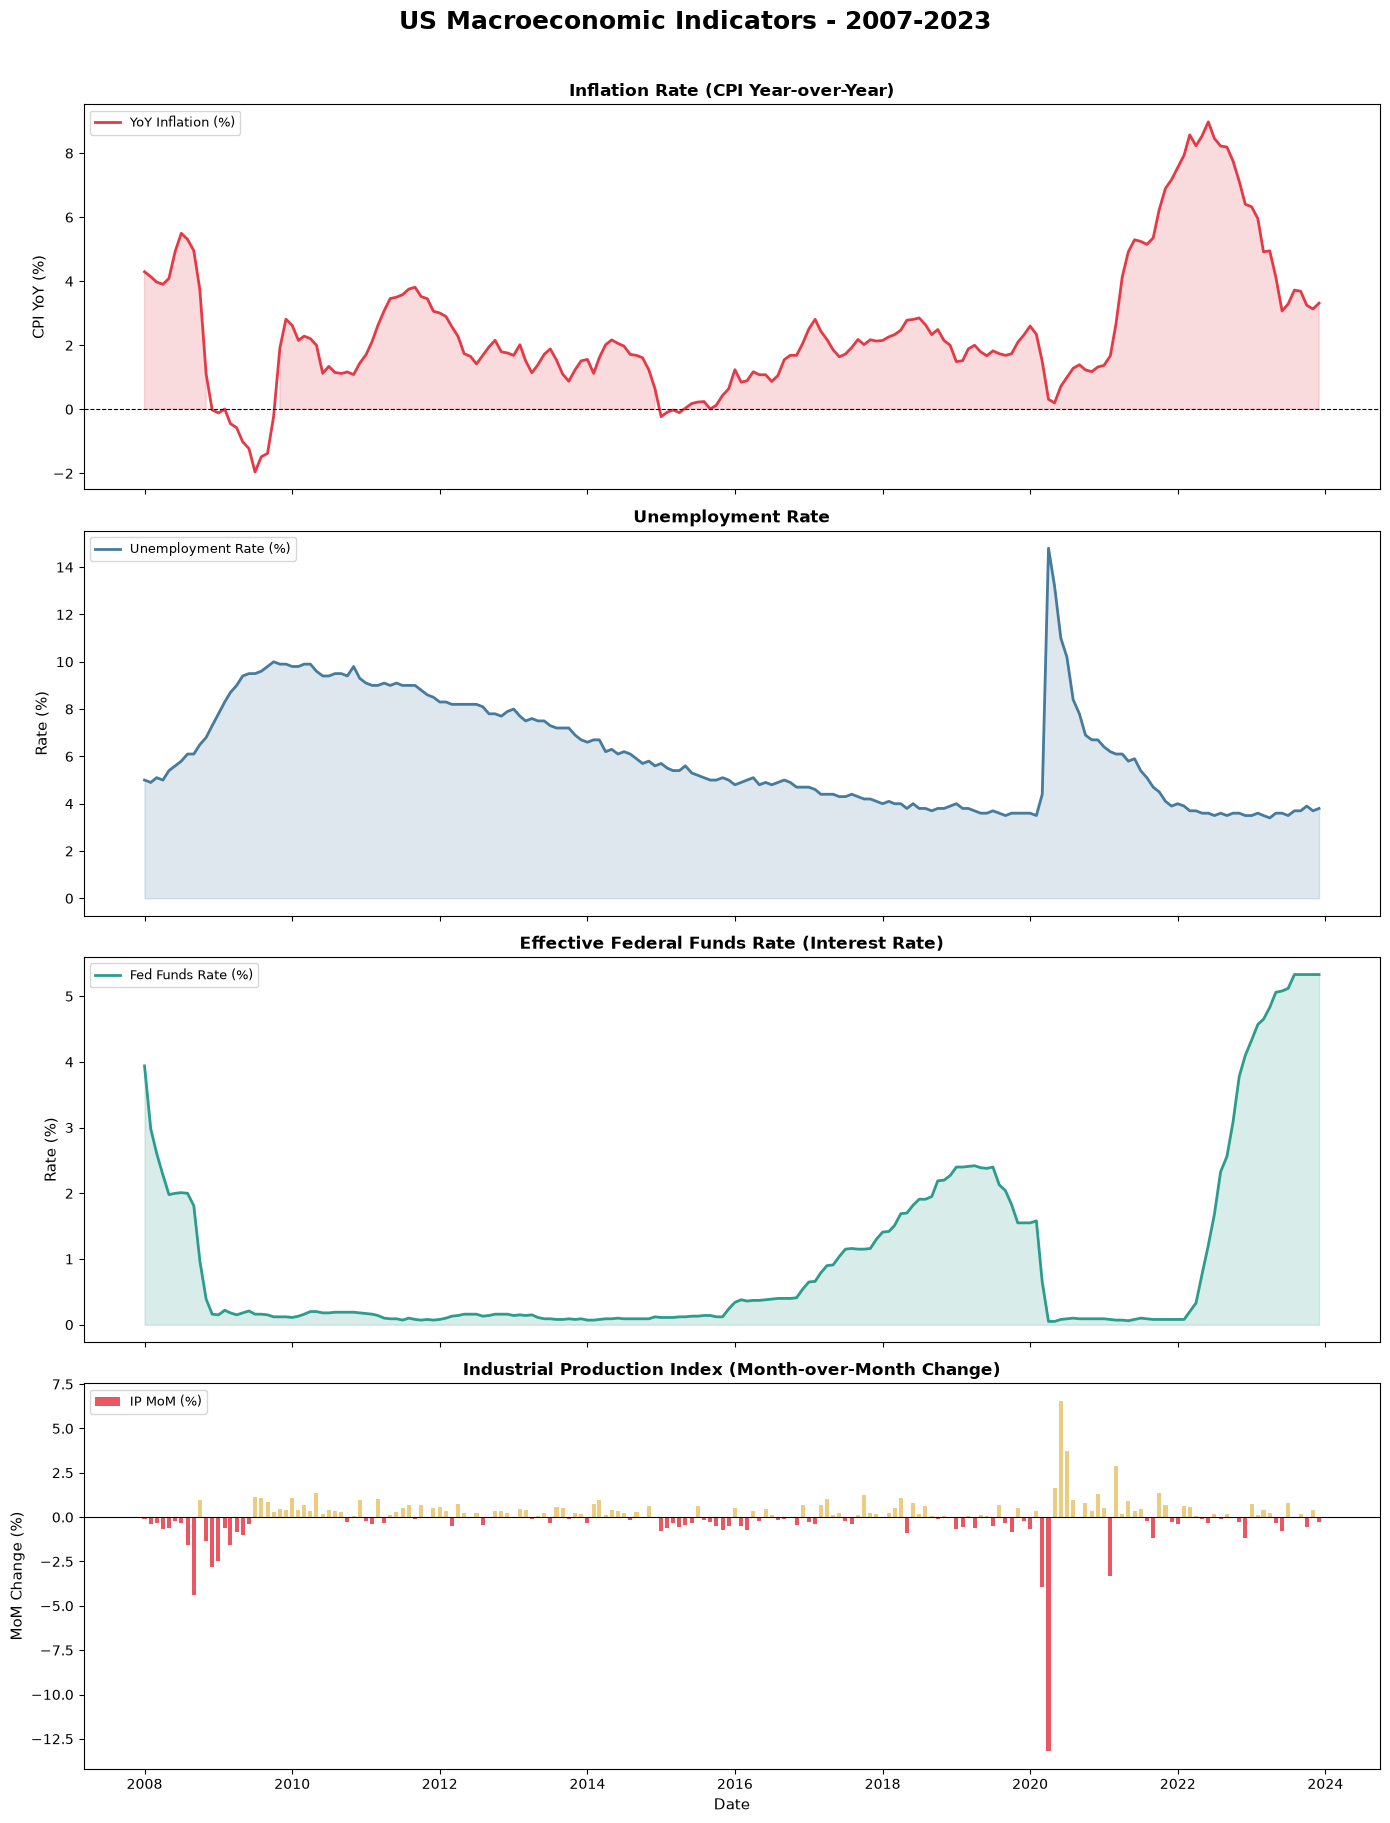

Plot saved to ../../plots/US/us_macro_indicators_2007_2023.png


In [ ]:
PALETTE = ["#E63946", "#457B9D", "#2A9D8F", "#E9C46A"]


fig, axes = plt.subplots(4, 1, figsize=(14, 18), sharex=True)
fig.suptitle("US Macroeconomic Indicators - 2007-2023",
             fontsize=18, fontweight="bold", y=1.01)

# Panel 1: Inflation YoY
ax = axes[0]
ax.plot(macro.index, macro["Inflation_YoY"], color=PALETTE[0],
        linewidth=2, label="YoY Inflation (%)")
ax.fill_between(macro.index, macro["Inflation_YoY"], 0,
                where=(macro["Inflation_YoY"] >= 0),
                alpha=0.18, color=PALETTE[0])
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_ylabel("CPI YoY (%)", fontsize=11)
ax.set_title("Inflation Rate (CPI Year-over-Year)", fontsize=12, fontweight="semibold")
ax.legend(fontsize=9, loc="upper left")

# Panel 2: Unemployment Rate
ax = axes[1]
ax.plot(macro.index, macro["UNRATE"], color=PALETTE[1],
        linewidth=2, label="Unemployment Rate (%)")
ax.fill_between(macro.index, macro["UNRATE"], alpha=0.18, color=PALETTE[1])
ax.set_ylabel("Rate (%)", fontsize=11)
ax.set_title("Unemployment Rate", fontsize=12, fontweight="semibold")
ax.legend(fontsize=9, loc="upper left")

# Panel 3: Federal Funds Rate
ax = axes[2]
ax.plot(macro.index, macro["FEDFUNDS"], color=PALETTE[2],
        linewidth=2, label="Fed Funds Rate (%)")
ax.fill_between(macro.index, macro["FEDFUNDS"], alpha=0.18, color=PALETTE[2])
ax.set_ylabel("Rate (%)", fontsize=11)
ax.set_title("Effective Federal Funds Rate (Interest Rate)",
             fontsize=12, fontweight="semibold")
ax.legend(fontsize=9, loc="upper left")

# Panel 4: Industrial Production MoM %
ax = axes[3]
bar_colors = [PALETTE[3] if v >= 0 else PALETTE[0] for v in macro["IP_MoM"]]
ax.bar(macro.index, macro["IP_MoM"], width=20,
       color=bar_colors, alpha=0.85, label="IP MoM (%)")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("MoM Change (%)", fontsize=11)
ax.set_title("Industrial Production Index (Month-over-Month Change)",
             fontsize=12, fontweight="semibold")
ax.legend(fontsize=9, loc="upper left")

# Shared x-axis
axes[-1].xaxis.set_major_locator(mdates.YearLocator(2))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[-1].set_xlabel("Date", fontsize=11)
plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=0, fontsize=10)

plt.tight_layout()

import os
os.makedirs("../../plots/US", exist_ok=True)
plt.savefig("../../plots/US/us_macro_indicators_2007_2023.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved to ../../plots/US/us_macro_indicators_2007_2023.png")

# FinBERT Sentiment Scoring

**Config & Load Raw News**

In [27]:
# import os, re
# import pandas as pd
#
# NEWS_PATH       = "../data/raw/news/FinSen_US_Categorized_Timestamp.csv"
# CHECKPOINT_DIR  = "../data/processed/finbert_checkpoints"
# FINAL_CACHE     = "../data/processed/finbert_article_scores.csv"
# BATCH_SIZE      = 128
# MAX_CHARS       = 512
#
# os.makedirs(CHECKPOINT_DIR, exist_ok=True)
# os.makedirs("../data/processed", exist_ok=True)
#
# def clean(text, max_chars=MAX_CHARS):
#     text = str(text)
#     text = re.sub(r"[^\x00-\x7F]+", " ", text)
#     text = re.sub(r"\s+", " ", text).strip()
#     return text[:max_chars]
#
# news_raw = pd.read_csv(NEWS_PATH)
# has_id = "article_id" in news_raw.columns
# cols = ["article_id", "Title", "Content", "Time"] if has_id else ["Title", "Content", "Time"]
# news_raw = news_raw[cols].copy()
# news_raw.rename(columns={"Time": "Date"}, inplace=True)
# news_raw["Date"] = pd.to_datetime(news_raw["Date"], dayfirst=True)
# news_raw = news_raw.dropna(subset=["Title", "Content", "Date"]).sort_values("Date").reset_index(drop=True)
# if not has_id:
#     news_raw["article_id"] = range(1, len(news_raw) + 1)
# news_raw["text"] = (
#     news_raw["Title"].apply(clean) + ". " + news_raw["Content"].apply(clean)
# ).str[:MAX_CHARS]
#
# print(f"Articles loaded : {len(news_raw)}")
# print(f"Date range      : {news_raw['Date'].min().date()} to {news_raw['Date'].max().date()}")
# news_raw.head(3)


**Load FinBERT Pipeline**

In [ ]:
# import torch
# import transformers
# from transformers import BertTokenizer, BertForSequenceClassification, pipeline

# device       = 0 if torch.cuda.is_available() else -1
# device_label = "GPU" if device == 0 else "CPU"
# print(f"transformers : {transformers.__version__}")
# print(f"torch        : {torch.__version__}")
# print(f"Device       : {device_label}")

# # Load model & tokenizer explicitly 
# tokenizer = BertTokenizer.from_pretrained("ProsusAI/finbert")
# model     = BertForSequenceClassification.from_pretrained("ProsusAI/finbert")

# finbert = pipeline(
#     "text-classification",
#     model=model,
#     tokenizer=tokenizer,
#     top_k=None,
#     device=device,
#     truncation=True,
#     max_length=512,
# )
# print("FinBERT ready.")


transformers : 5.14.1
torch        : 2.13.0+cpu
Device       : CPU


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 11496.26it/s]

FinBERT ready.


**Batch Inference with Per-Batch Checkpointing**

In [ ]:
# # Safe to re-run after a crash: already-scored batches are automatically skipped.
# from tqdm.auto import tqdm
# import os
#
# def net_score(preds):
#     """P(positive) - P(negative) net sentiment."""
#     prob = {p["label"]: p["score"] for p in preds}
#     return prob.get("positive", 0.0) - prob.get("negative", 0.0)
#
# texts     = news_raw["text"].tolist()
# n_batches = (len(texts) + BATCH_SIZE - 1) // BATCH_SIZE
#
# # ── Detect already-completed batches
# existing = {
#     int(f.split("_")[1].split(".")[0])
#     for f in os.listdir(CHECKPOINT_DIR)
#     if f.startswith("batch_") and f.endswith(".csv")
# }
# pending = [i for i in range(n_batches) if i not in existing]
#
# print(f"Total batches : {n_batches}")
# print(f"Already done  : {len(existing)}")
# print(f"Remaining     : {len(pending)}")
#
# for batch_idx in tqdm(pending, desc="FinBERT batches"):
#     start = batch_idx * BATCH_SIZE
#     end   = min(start + BATCH_SIZE, len(texts))
#     batch_texts = texts[start:end]
#
#     try:
#         out = finbert(batch_texts)
#     except Exception as exc:
#         print(f"  [!] Batch {batch_idx} failed: {exc}  – skipping")
#         continue
#
#     cols = ["article_id", "Date", "Title"] if "article_id" in news_raw.columns else ["Date", "Title"]
#     batch_df = news_raw.iloc[start:end][cols].copy().reset_index(drop=True)
#     batch_df["Sentiment_Score"] = [net_score(r) for r in out]
#     batch_df["Label"]           = [max(r, key=lambda x: x["score"])["label"] for r in out]
#
#     ckpt_path = os.path.join(CHECKPOINT_DIR, f"batch_{batch_idx:05d}.csv")
#     batch_df.to_csv(ckpt_path, index=False)
#
# print(f"\nInference complete (or resumed). Checkpoint files in {CHECKPOINT_DIR}:",
#       len(os.listdir(CHECKPOINT_DIR)))


Total batches : 122
Already done  : 0
Remaining     : 122


FinBERT batches: 100%|██████████| 122/122 [38:23<00:00, 18.88s/it]


Inference complete (or resumed). Checkpoint files in ../data/processed/finbert_checkpoints: 122


**Assemble scores_df from Checkpoints & Save Final Cache**

In [ ]:
# import glob
# import pandas as pd
# import os

# ckpt_files = sorted(glob.glob(os.path.join(CHECKPOINT_DIR, "batch_*.csv")))
# if not ckpt_files:
#     raise RuntimeError("No checkpoint files found – run Cell 10c first.")

# scores_df = pd.concat(
#     [pd.read_csv(f, parse_dates=["Date"]) for f in ckpt_files],
#     ignore_index=True
# ).sort_values("Date").reset_index(drop=True)

# scores_df.to_csv(FINAL_CACHE, index=False)
# print(f"Final cache saved  : {FINAL_CACHE}")
# print(f"Total articles     : {len(scores_df)}")
# print(f"Date range         : {scores_df['Date'].min().date()} to {scores_df['Date'].max().date()}")
# scores_df.head()


Final cache saved  : ../data/processed/finbert_article_scores.csv
Total articles     : 15534
Date range         : 2007-06-04 to 2023-07-16


,Date,Title,Sentiment_Score,Label
0,2007-06-04,Blackstone boosts IPO after Beijing takes $3bn...,0.896313,positive
1,2007-06-04,Trade Deficit Increases in March 2007,0.423146,positive
2,2007-06-06,Consumer Price Index 2.6 percent higher than i...,0.866791,positive
3,2007-06-06,"Nonfarm payroll employment increased by 157,00...",0.705183,positive
4,2007-06-06,U.S. Federal Reserve Kept Rates Unchanged at 5...,-0.149566,neutral


**Monthly Aggregation & Sentiment Plot**

Monthly sentiment computed for 194 months
Period: 2007-06-01 to 2023-07-01


findfont: Failed to find font weight semibold, now using 700.


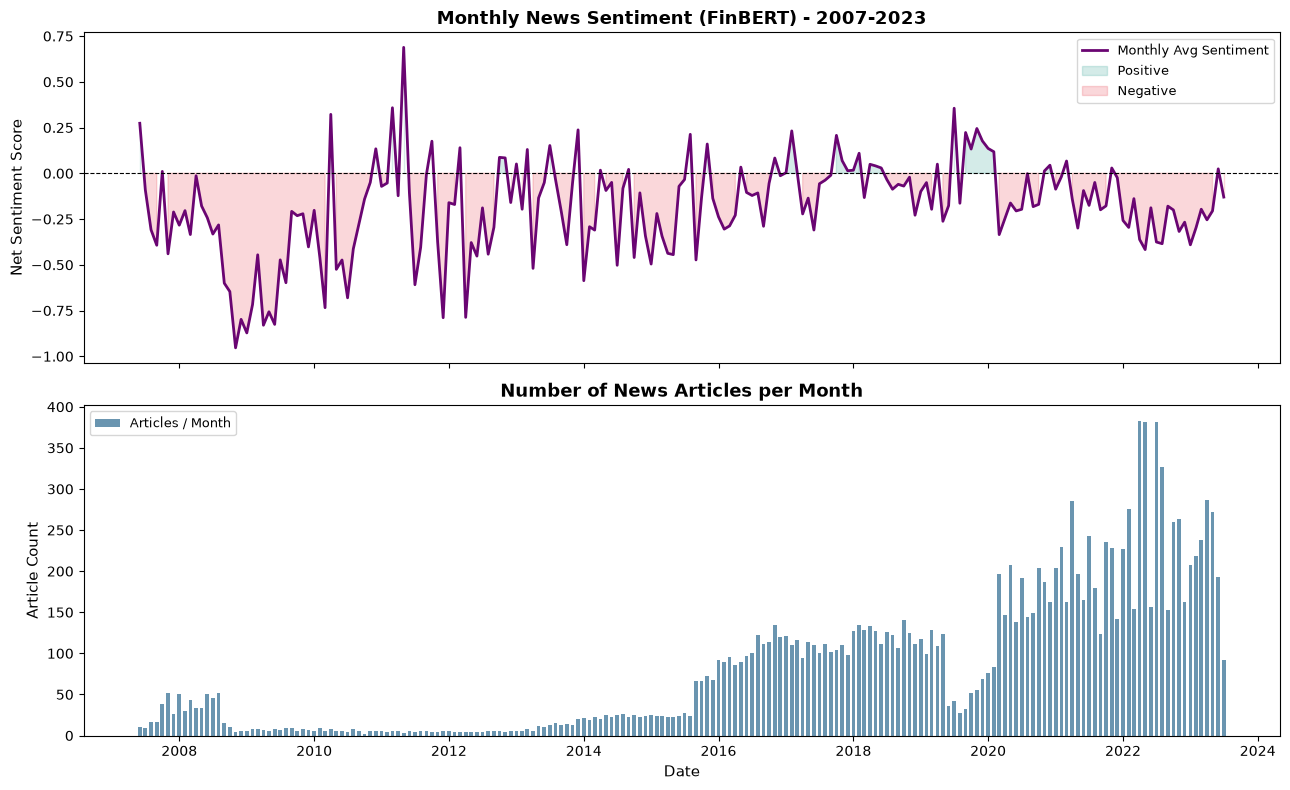

Sentiment plot saved to ../../plots/US/us_news_sentiment_2007_2023.png


In [ ]:
# # Monthly mean sentiment score and article count
# scores_df["Date"]  = pd.to_datetime(scores_df["Date"])
# scores_df["Month"] = scores_df["Date"].dt.to_period("M").dt.to_timestamp()

# monthly_sent = (
#     scores_df
#     .groupby("Month")
#     .agg(
#         News_Sentiment=("Sentiment_Score", "mean"),
#         Article_Count=("Sentiment_Score", "count"),
#     )
#     .rename_axis("Date")
# )

# print("Monthly sentiment computed for", len(monthly_sent), "months")
# print("Period:", monthly_sent.index[0].date(), "to", monthly_sent.index[-1].date())

# # ── Plot: sentiment over time
# fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

# ax = axes[0]
# ax.plot(monthly_sent.index, monthly_sent["News_Sentiment"],
#         color="#6A0572", linewidth=2, label="Monthly Avg Sentiment")
# ax.fill_between(monthly_sent.index, monthly_sent["News_Sentiment"], 0,
#                 where=(monthly_sent["News_Sentiment"] >= 0),
#                 alpha=0.2, color="#2A9D8F", label="Positive")
# ax.fill_between(monthly_sent.index, monthly_sent["News_Sentiment"], 0,
#                 where=(monthly_sent["News_Sentiment"] < 0),
#                 alpha=0.2, color="#E63946", label="Negative")
# ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
# ax.set_ylabel("Net Sentiment Score", fontsize=11)
# ax.set_title("Monthly News Sentiment (FinBERT) - 2007-2023",
#              fontsize=13, fontweight="semibold")
# ax.legend(fontsize=9)

# ax = axes[1]
# ax.bar(monthly_sent.index, monthly_sent["Article_Count"],
#        width=20, color="#457B9D", alpha=0.8, label="Articles / Month")
# ax.set_ylabel("Article Count", fontsize=11)
# ax.set_title("Number of News Articles per Month", fontsize=13, fontweight="semibold")
# ax.legend(fontsize=9)

# axes[-1].xaxis.set_major_locator(mdates.YearLocator(2))
# axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
# axes[-1].set_xlabel("Date", fontsize=11)
# plt.tight_layout()
# plt.savefig("../../plots/US/us_news_sentiment_2007_2023.png", dpi=150, bbox_inches="tight")
# plt.show()
# print("Sentiment plot saved to ../../plots/US/us_news_sentiment_2007_2023.png")

**Merge with Macro Data & Save Final Dataset**

In [ ]:
# import os

# # Align monthly sentiment index with macro DataFrame index
# monthly_sent.index = pd.to_datetime(monthly_sent.index)
# macro.index        = pd.to_datetime(macro.index)

# # Left-join so all macro months are kept; sentiment is NaN where no articles exist
# df_final = macro.join(monthly_sent[["News_Sentiment", "Article_Count"]], how="left")
# df_final = df_final[df_final.index <= "2023-07-01"]

# print("Merge summary:")
# print("  Macro rows            :", len(macro))
# print("  Months with sentiment :", df_final["News_Sentiment"].notna().sum())
# print("  Months without        :", df_final["News_Sentiment"].isna().sum())

# # Save final processed dataset
# os.makedirs("../../data/processed/US", exist_ok=True)
# out_path = "../../data/processed/US/us_macro_2007_2023.csv"
# df_final.to_csv(out_path)

# print("\nProcessed dataset saved to", out_path)
# print("  Shape   :", df_final.shape)
# print("  Columns :", list(df_final.columns))
# print("  Period  :", df_final.index[0].date(), "to", df_final.index[-1].date())
# df_final.tail()

Merge summary:
  Macro rows            : 192
  Months with sentiment : 187
  Months without        : 0

Processed dataset saved to ../../data/processed/US/us_macro_2007_2023.csv
  Shape   : (187, 9)
  Columns : ['CPIAUCSL', 'UNRATE', 'FEDFUNDS', 'INDPRO', 'Inflation_MoM', 'Inflation_YoY', 'IP_MoM', 'News_Sentiment', 'Article_Count']
  Period  : 2008-01-01 to 2023-07-01


,CPIAUCSL,UNRATE,FEDFUNDS,INDPRO,Inflation_MoM,Inflation_YoY,IP_MoM,News_Sentiment,Article_Count
Date,,,,,,,,,
2023-03-01,301.821,3.5,4.65,101.0205,0.123072,4.917719,0.376484,-0.196047,238.0
2023-04-01,302.845,3.4,4.83,101.2530,0.339274,4.950080,0.230151,-0.253937,287.0
2023-05-01,303.334,3.6,5.06,100.9286,0.161469,4.131851,-0.320386,-0.205241,272.0
2023-06-01,304.014,3.6,5.08,100.1196,0.224175,3.070617,-0.801557,0.024506,193.0
2023-07-01,304.609,3.5,5.12,100.9067,0.195715,3.287749,0.786160,-0.129720,92.0


**Insert Scored News → `core.core_daily_news`**


In [22]:
# ── (Re-)load scored articles from the final cache if scores_df is not in memory ─
import os, glob, pandas as pd

FINAL_CACHE    = '../data/processed/finbert_article_scores.csv'
RAW_NEWS_PATH  = '../data/raw/news/FinSen_US_Categorized_Timestamp.csv'

if 'scores_df' not in dir() or scores_df is None:
    print('scores_df not found in memory – loading from cache...')
    scores_df = pd.read_csv(FINAL_CACHE, parse_dates=['Date'])
    print(f'  Loaded {len(scores_df)} scored rows from {FINAL_CACHE}')
else:
    print(f'scores_df already in memory: {len(scores_df)} rows')

# Load the original raw CSV to retrieve the Source/Category column if available
if os.path.exists(RAW_NEWS_PATH):
    raw_cols = pd.read_csv(RAW_NEWS_PATH, nrows=1).columns.tolist()
    print(f'Raw CSV columns: {raw_cols}')
else:
    raw_cols = []
    print(f'Raw CSV not found at {RAW_NEWS_PATH} – source_name will be hard-coded.')


scores_df already in memory: 15534 rows
Raw CSV columns: ['Title', 'Tag', 'Time', 'Content']


In [23]:
# ── Build the insert DataFrame for core.daily_news ───────────────────────────
import os, re
import pandas as pd
from sqlalchemy import text

RAW_CSV_ABS_PATH = os.path.abspath(RAW_NEWS_PATH)   # used as lake_pointer_url

# Query US region_id
with engine.connect() as con:
    us_region = con.execute(text("SELECT region_id FROM core.source_regions WHERE region_code = 'US'")).scalar()
    if not us_region:
        us_region = 1

# ── Fetch existing titles from DB ────────────────
with engine.connect() as con:
    existing_db = pd.read_sql(
        text('SELECT news_date, title FROM core.daily_news'), 
        con
    )

def norm_text(t):
    if not t or pd.isna(t):
        return ''
    return re.sub(r'\s+', ' ', str(t)).strip().lower()[:500]

existing_norm_titles = set(existing_db['title'].apply(norm_text))

news_insert = pd.DataFrame({
    'news_date'       : pd.to_datetime(scores_df['Date']).dt.date,
    'title'           : scores_df['Title'].str[:500],               # VARCHAR(500)
    'source_name'     : 'kaggle',
    'region_id'       : us_region,
    'sentiment_score' : scores_df['Sentiment_Score'].astype(float),
    'sentiment_label' : scores_df['Label'].str[:50],                # VARCHAR(50)
    'lake_pointer_url': RAW_CSV_ABS_PATH[:500],                     # VARCHAR(500)
})

# Drop rows where title or date is null
news_insert = news_insert.dropna(subset=['news_date', 'title']).reset_index(drop=True)

# ── BULLETPROOF EXISTENCE CHECK ─────────────────────────────────────────────
is_title_dup = news_insert['title'].apply(norm_text).isin(existing_norm_titles)

before_count = len(news_insert)
news_insert = news_insert[~is_title_dup].reset_index(drop=True)
skipped_count = before_count - len(news_insert)

print(f'Articles in input dataset   : {before_count}')
print(f'Articles skipped (exist DB) : {skipped_count}')
print(f'New articles to insert      : {len(news_insert)}')

if len(news_insert) > 0:
    print(news_insert.dtypes)
    print(news_insert.head(3))
else:
    print('All article titles already exist in the database.')


Current max article_id in DB : 0
Rows to insert     : 15534
article_id range   : 1 – 15534
lake_pointer_url   : d:\Master Semester 4\ADM\Project\Advanced-Data-Management\data\raw\news\FinSen_US_Categorized_Timestamp.csv
article_id            int64
news_date            object
title                   str
source_name             str
source_region           str
sentiment_score     float64
sentiment_label         str
lake_pointer_url        str
dtype: object


,article_id,news_date,title,source_name,source_region,sentiment_score,sentiment_label,lake_pointer_url
0,1,2007-06-04,Blackstone boosts IPO after Beijing takes $3bn...,kaggle,US,0.896313,positive,d:\Master Semester 4\ADM\Project\Advanced-Data...
1,2,2007-06-04,Trade Deficit Increases in March 2007,kaggle,US,0.423146,positive,d:\Master Semester 4\ADM\Project\Advanced-Data...
2,3,2007-06-06,Consumer Price Index 2.6 percent higher than i...,kaggle,US,0.866791,positive,d:\Master Semester 4\ADM\Project\Advanced-Data...


In [25]:
# ── Bulk-insert daily_news ─
# We chunk the DataFrame and insert batch-by-batch
import math

if len(news_insert) == 0:
    print('No new articles to insert. Skipping insert.')
else:
    CHUNK = 250   # rows per transaction

    total_rows = len(news_insert)
    n_chunks   = math.ceil(total_rows / CHUNK)
    inserted   = 0

    for chunk_idx in range(n_chunks):
        chunk_df = news_insert.iloc[chunk_idx * CHUNK : (chunk_idx + 1) * CHUNK]

        with engine.begin() as con:
            chunk_df.to_sql(
                name      = 'daily_news',
                schema    = 'core',
                con       = con,
                if_exists = 'append',
                index     = False,
                chunksize = CHUNK,
                method    = 'multi',
            )

        inserted += len(chunk_df)
        print(f'  Chunk {chunk_idx+1}/{n_chunks} done  ({inserted}/{total_rows} rows)')

    print(f'\ncore.daily_news  →  {inserted} new rows inserted.')

# Verify
with engine.connect() as con:
    cnt = con.execute(text('SELECT COUNT(*) FROM core.daily_news')).scalar()
    sample = con.execute(text(
        'SELECT TOP 3 article_id, news_date, title, sentiment_score, sentiment_label ' 
        'FROM core.daily_news ORDER BY article_id'
    )).fetchall()
print(f'Table now contains : {cnt} total rows')
for r in sample:
    print(' ', r)


  Chunk 1/63 done  (250/15534 rows)
  Chunk 2/63 done  (500/15534 rows)
  Chunk 3/63 done  (750/15534 rows)
  Chunk 4/63 done  (1000/15534 rows)
  Chunk 5/63 done  (1250/15534 rows)
  Chunk 6/63 done  (1500/15534 rows)
  Chunk 7/63 done  (1750/15534 rows)
  Chunk 8/63 done  (2000/15534 rows)
  Chunk 9/63 done  (2250/15534 rows)
  Chunk 10/63 done  (2500/15534 rows)
  Chunk 11/63 done  (2750/15534 rows)
  Chunk 12/63 done  (3000/15534 rows)
  Chunk 13/63 done  (3250/15534 rows)
  Chunk 14/63 done  (3500/15534 rows)
  Chunk 15/63 done  (3750/15534 rows)
  Chunk 16/63 done  (4000/15534 rows)
  Chunk 17/63 done  (4250/15534 rows)
  Chunk 18/63 done  (4500/15534 rows)
  Chunk 19/63 done  (4750/15534 rows)
  Chunk 20/63 done  (5000/15534 rows)
  Chunk 21/63 done  (5250/15534 rows)
  Chunk 22/63 done  (5500/15534 rows)
  Chunk 23/63 done  (5750/15534 rows)
  Chunk 24/63 done  (6000/15534 rows)
  Chunk 25/63 done  (6250/15534 rows)
  Chunk 26/63 done  (6500/15534 rows)
  Chunk 27/63 done  (675

**Verification**

In [26]:
queries = {
    'Macro – row count & date range': """
        SELECT
            COUNT(*)       AS total_rows,
            MIN(month_date) AS earliest,
            MAX(month_date) AS latest,
            source_agency
        FROM core.monthly_macro_indicators
        GROUP BY source_agency
    """,
    'Macro – first 5 rows': """
        SELECT TOP 5 *
        FROM core.monthly_macro_indicators
        ORDER BY month_date
    """,
    'News – row count & date range': """
        SELECT
            COUNT(*)        AS total_rows,
            MIN(news_date)  AS earliest,
            MAX(news_date)  AS latest,
            source_name,
            region_id
        FROM core.daily_news
        GROUP BY source_name, region_id
    """,
    'News – first 5 rows': """
        SELECT TOP 5 article_id, news_date, title, sentiment_score, sentiment_label
        FROM core.daily_news
        ORDER BY news_date
    """,
}

with engine.connect() as con:
    for label, sql in queries.items():
        print(f'\n{"─"*60}')
        print(f'  {label}')
        print(f'{"─"*60}')
        df = pd.read_sql(text(sql), con)
        print(df.to_string(index=False))



────────────────────────────────────────────────────────────
  Macro – row count & date range
────────────────────────────────────────────────────────────
 total_rows   earliest     latest source_agency
        204 2007-01-01 2023-12-01          FRED

────────────────────────────────────────────────────────────
  Macro – first 5 rows
────────────────────────────────────────────────────────────
 record_id month_date source_agency country  cpi_value  unemployment_rate  fed_funds_rate  ind_production_value
         1 2007-01-01          FRED      US    203.437                4.6            5.25               99.8346
         2 2007-02-01          FRED      US    204.226                4.5            5.26              100.7753
         3 2007-03-01          FRED      US    205.288                4.4            5.26              100.9547
         4 2007-04-01          FRED      US    205.904                4.5            5.25              101.6334
         5 2007-05-01          FRED      U